# Soil moisture (HydroSense HS2, consolidated workbook)

Reads the consolidated multi-sheet HydroSense workbook (one sheet per date+site).
Each sheet name encodes date and site code, e.g. `05142026 JAP`, `5192026 DLP`.

For each sheet the notebook extracts **two** measurement blocks — Volumetric Water
Content (%) and sensor period (µs) — averages the four cardinal directions (N, S, E, W)
per sub-site, and computes the standard deviation. Instrument serial number and full
site name are captured per sheet for provenance.

The notebook then builds several analyses:

1. Mean VWC through time, and mean-centered VWC anomaly, for all sub-sites.
2. A provenance audit of instrument serial numbers across sites and dates.
3. VWC-vs-period scatter, recovering the HS2's proprietary period→VWC calibration
   as an empirical fit, with per-site fit residuals.
4. Land-use VWC anomalies, comparing prairie and lawn-alternative plots against a
   per-site turf baseline.

Adapted to Python from M. Berkelhammer's MATLAB script
`plot_soil_moisture_timeseries_publication.m`, then extended.

## References

- [Working Document](https://docs.google.com/document/d/1VHoEu4XzWOyjzqc09gZnij4bLPgIV7TGgo3kzkCU1vk/edit?usp=sharing) — shared notes and data-entry guide
- [Site Map](https://www.google.com/maps/d/u/0/viewer?mid=1uB4ttvWR_08REucJg3zxK_lcAD0XomM&ll=41.90117053440477%2C-87.62460811259766&z=13) — sub-site locations
- [Campbell HydroSense II (HS2)](https://www.campbellsci.com/hs2) — handheld soil moisture sensor
- [HS2 Manual (PDF)](https://s.campbellsci.com/documents/us/manuals/hs2.pdf)

## Documentation notes (important)

Two known issues with the source workbook are handled or flagged here:

**1. The second data block is mislabeled "Conductivity."** The HS2 does **not** measure
conductivity. The second number the instrument reports is the **period in microseconds**
(µs) — the raw quantity the HS2 measures, from which VWC is derived. This notebook
extracts that block and labels it `Period_us`, *not* conductivity. Block values cluster
around 1.2–1.6, consistent with period (µs) and inconsistent with conductivity (dS/m).

**2. Horner Park (HCP) switched instruments midway.** The HS2 used at HCP early in the
campaign was borrowed from Northwestern; it was later swapped for a different unit. The
HCP sheets do **not** record a serial number, so that provenance is missing exactly where
it matters most. Serial numbers also change for MUC/NIB over time (4849 → 4859) and some
sheets note the serial "unless specified in Locations." The notebook captures the serial
verbatim and flags missing/ambiguous cases rather than assuming one instrument per site.

## 1. User settings

In [25]:
import glob
import os
import re
import subprocess
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.offsetbox import AnchoredText

try:
    import openpyxl  # noqa: F401
except ModuleNotFoundError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "openpyxl"]
    )

In [ ]:
dataDir = os.path.join("data", "soil")   # input workbook + cleaned CSV
figDir  = "figures"                       # generated figures

# Consolidated workbook (one sheet per date+site). Point this at your file.
fileName = os.path.join(dataDir, "Data_Entry_All_Sites__DO_NOT_EDIT__gsheet.xlsx")

saveFigures  = True
saveCleanCSV = True
exportBackground = "white"

os.makedirs(dataDir, exist_ok=True)
os.makedirs(figDir, exist_ok=True)

## 2. Locate the workbook

In [27]:
if not os.path.isfile(fileName):
    xl = [f for f in glob.glob(os.path.join(dataDir, "*.xlsx"))
          if not os.path.basename(f).startswith("~$")]
    if len(xl) == 1:
        fileName = xl[0]
        print(f"Using workbook found in {dataDir}: {fileName}")
    elif not xl:
        raise FileNotFoundError(
            f"Could not find {fileName} and no .xlsx files were found in {dataDir}.")
    else:
        raise FileNotFoundError(
            f"Could not find {fileName}. Multiple .xlsx files found in {dataDir}; set fileName manually.")

Using workbook found in data/soil: data/soil/Data Entry All Sites (DO NOT EDIT)_gsheet.xlsx


## 3. Helper functions

`parse_sheet_name`, a numeric coercion helper, a serial/site-name reader, and the
dual-block extractor. Kept separate from the execution cells below.

In [28]:
def parse_sheet_name(sheet_name):
    """Parse names like '05142026 JAP', '5192026 DLP' into (Timestamp, site_code)."""
    m = re.match(r"^(\d{7,8})\s+(.+)$", sheet_name.strip())
    if not m:
        raise ValueError(f"Could not parse sheet name: {sheet_name}")
    d, site_code = m.group(1), m.group(2).strip()
    yr = int(d[-4:])
    mdpart = d[:-4]
    if len(mdpart) == 4:
        mo, dy = int(mdpart[:2]), int(mdpart[2:4])
    elif len(mdpart) == 3:
        mo, dy = int(mdpart[:1]), int(mdpart[1:3])
    else:
        raise ValueError(f"Could not parse month/day from sheet name: {sheet_name}")
    return pd.Timestamp(year=yr, month=mo, day=dy), site_code


def _to_double(v):
    """numbers pass through; blanks/missing -> NaN; parseable strings -> float; else NaN."""
    if isinstance(v, (int, float, np.integer, np.floating)):
        return float(v)
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return np.nan
    s = str(v).strip()
    if s == "" or s.lower() == "nan":
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan


def _cell_str(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return ""
    return str(v).strip()


def read_serial_and_site(C):
    """Return (serial_raw, serial_num, site_fullname) from the sheet header rows.

    serial_raw is whatever text sits next to 'Serial Number:' (may be empty, a clean
    number, or a caveat like '4859 (unless specified in Locations)'). serial_num is the
    first integer found in that text, else NaN. site_fullname is the descriptive name
    (e.g. 'HORNER PARK') from the row below the instrument line."""
    n_rows, n_cols = C.shape
    serial_raw, serial_num, site_fullname = "", np.nan, ""

    for r in range(min(4, n_rows)):
        for c in range(n_cols):
            if "serial" in _cell_str(C[r, c]).lower():
                # value is the next non-empty cell to the right
                for cc in range(c + 1, n_cols):
                    s = _cell_str(C[r, cc])
                    if s:
                        serial_raw = s
                        break
                break
        if serial_raw:
            break

    m = re.search(r"(\d{3,})", serial_raw)
    if m:
        serial_num = int(m.group(1))

    # full site name: typically row 1, column 0
    if n_rows > 1:
        site_fullname = _cell_str(C[1, 0])

    return serial_raw, serial_num, site_fullname

In [29]:
def find_nsew_headers(C):
    """Return the row indices of every header row whose columns 2:5 are N S E W."""
    headers = []
    for r in range(C.shape[0]):
        vals = [_cell_str(C[r, c]).upper() for c in range(1, 5)]
        if vals == ["N", "S", "E", "W"]:
            headers.append(r)
    return headers


def read_block(C, header_row, value_name):
    """Read one N/S/E/W block starting below header_row, until a blank column-A cell,
    a 'Control' row, or an all-non-numeric row. Returns a list of dicts."""
    rows = []
    for r in range(header_row + 1, C.shape[0]):
        loc = _cell_str(C[r, 0])
        if loc == "" or loc.lower() == "nan":
            break
        if "control" in loc.lower():
            break
        vals = np.array([_to_double(C[r, c]) for c in range(1, 5)])
        # An all-NaN row with a valid sub-site label is a recorded-but-missing
        # location (e.g. "na" readings, "Blocked by construction"), NOT the end of
        # the block. Keep it as NaN data and continue. Only the label/Control/blank
        # checks above terminate the block.
        n_v = int(np.sum(~np.isnan(vals)))
        rows.append({
            "SubSite": loc,
            f"{value_name}_N": vals[0], f"{value_name}_S": vals[1],
            f"{value_name}_E": vals[2], f"{value_name}_W": vals[3],
            f"Mean{value_name}": np.nanmean(vals),
            f"SD{value_name}": np.nanstd(vals, ddof=1) if n_v > 1 else np.nan,
            f"Ndirs_{value_name}": n_v,
        })
    return rows


def extract_sheet(C, sample_date, site_code, sheet_name):
    """Extract the VWC block (first N/S/E/W header) and the Period block (second
    header, mislabeled 'Conductivity' in the source). Merge on SubSite. Attach
    date, site, serial and full-site-name provenance."""
    headers = find_nsew_headers(C)
    if not headers:
        print(f"WARNING: no N/S/E/W header found in sheet: {sheet_name}")
        return pd.DataFrame()

    vwc = pd.DataFrame(read_block(C, headers[0], "VWC"))
    if vwc.empty:
        print(f"WARNING: no VWC rows extracted from sheet: {sheet_name}")
        return pd.DataFrame()

    if len(headers) >= 2:
        period = pd.DataFrame(read_block(C, headers[1], "Period"))
    else:
        period = pd.DataFrame(columns=["SubSite"])

    # merge VWC + period on SubSite, preserving VWC row order
    df = vwc.merge(period, on="SubSite", how="left") if not period.empty else vwc

    serial_raw, serial_num, site_fullname = read_serial_and_site(C)
    df.insert(0, "Date", sample_date)
    df.insert(1, "Site", site_code)
    df["SiteName"] = site_fullname
    df["SerialRaw"] = serial_raw
    df["Serial"] = serial_num
    df["SerialAmbiguous"] = bool(serial_raw) and not bool(re.fullmatch(r"\d{3,}", serial_raw))
    df["SerialMissing"] = (serial_raw == "")
    df["Sheet"] = sheet_name
    return df

## 4. Read all sheets

In [30]:
book = pd.read_excel(fileName, sheet_name=None, header=None)

frames = []
for sheet_name, sheet_df in book.items():
    sample_date, site_code = parse_sheet_name(sheet_name)
    C = sheet_df.to_numpy(dtype=object)
    T = extract_sheet(C, sample_date, site_code, sheet_name)
    if not T.empty:
        frames.append(T)

All = pd.concat(frames, ignore_index=True)

# Unique plotting label; keeps same-named sub-sites at different sites separate.
All["SiteSubSite"] = All["Site"].astype(str) + " " + All["SubSite"].astype(str)
All = All.sort_values(["Site", "SubSite", "Date"]).reset_index(drop=True)

print(f"{len(All)} rows | {All['SiteSubSite'].nunique()} sub-sites | "
      f"{All['Site'].nunique()} sites | {All['Date'].nunique()} dates")
All.head()

198 rows | 38 sub-sites | 5 sites | 12 dates


/tmp/ipykernel_31260/1051637098.py:31: RuntimeWarning: Mean of empty slice
  f"Mean{value_name}": np.nanmean(vals),


,Date,Site,SubSite,VWC_N,VWC_S,VWC_E,VWC_W,MeanVWC,SDVWC,Ndirs_VWC,...,MeanPeriod,SDPeriod,Ndirs_Period,SiteName,SerialRaw,Serial,SerialAmbiguous,SerialMissing,Sheet,SiteSubSite
0,2026-05-19,DLP,DLP lawn alternative 1,24.9,31.4,31.3,29.4,29.250,3.042477,4,...,1.53375,0.056417,4.0,LINCOLN PARK,,NaN,False,True,5192026 DLP,DLP DLP lawn alternative 1
1,2026-05-26,DLP,DLP lawn alternative 1,31.5,31.9,27.8,27.0,29.550,2.509316,4,...,1.55925,0.033974,4.0,LINCOLN PARK,,NaN,False,True,5262026 DLP,DLP DLP lawn alternative 1
2,2026-06-02,DLP,DLP lawn alternative 1,10.3,21.5,13.7,14.8,15.075,4.692103,4,...,1.34275,0.073889,4.0,LINCOLN PARK,,NaN,False,True,06022026 DLP,DLP DLP lawn alternative 1
3,2026-06-09,DLP,DLP lawn alternative 1,12.7,18.5,29.7,25.2,21.525,7.469215,4,...,1.44325,0.114033,4.0,LINCOLN PARK,,NaN,False,True,06092026 DLP,DLP DLP lawn alternative 1
4,2026-06-16,DLP,DLP lawn alternative 1,24.1,27.9,32.6,28.4,28.250,3.478026,4,...,1.54550,0.053251,4.0,LINCOLN PARK,,NaN,False,True,06162026 DLP,DLP DLP lawn alternative 1


## 5. Provenance check: serial numbers

Surfaces the instrument-serial situation per site/date, including the missing HCP
serials and any ambiguous entries, so the gaps are explicit rather than silent.

In [31]:
prov = (All.groupby(["Site", "Date"])
           .agg(SerialRaw=("SerialRaw", "first"),
                Serial=("Serial", "first"),
                Missing=("SerialMissing", "first"),
                Ambiguous=("SerialAmbiguous", "first"))
           .reset_index()
           .sort_values(["Site", "Date"]))

print("Distinct serials seen per site:")
for site, g in prov.groupby("Site"):
    serials = sorted({int(s) for s in g["Serial"].dropna().unique()})
    n_missing = int(g["Missing"].sum())
    note = f"  ({n_missing} sheet(s) with NO serial recorded)" if n_missing else ""
    print(f"  {site}: {serials if serials else 'none recorded'}{note}")

print()
flagged = prov[prov["Missing"] | prov["Ambiguous"]]
if not flagged.empty:
    print("Sheets with missing or ambiguous serials:")
    for _, r in flagged.iterrows():
        kind = "MISSING" if r["Missing"] else "ambiguous"
        print(f"  {r['Site']} {r['Date'].date()}  [{kind}]  {r['SerialRaw']!r}")
prov

Distinct serials seen per site:
  DLP: none recorded  (5 sheet(s) with NO serial recorded)
  HCP: none recorded  (6 sheet(s) with NO serial recorded)
  JAP: [4825]
  MUC: [4849, 4859]
  NIB: [4849, 4859]

Sheets with missing or ambiguous serials:
  DLP 2026-05-19  [MISSING]  ''
  DLP 2026-05-26  [MISSING]  ''
  DLP 2026-06-02  [MISSING]  ''
  DLP 2026-06-09  [MISSING]  ''
  DLP 2026-06-16  [MISSING]  ''
  HCP 2026-05-19  [MISSING]  ''
  HCP 2026-05-26  [MISSING]  ''
  HCP 2026-06-02  [MISSING]  ''
  HCP 2026-06-09  [MISSING]  ''
  HCP 2026-06-16  [MISSING]  ''
  HCP 2026-06-23  [MISSING]  ''
  MUC 2026-06-02  [ambiguous]  '4859 (unless specified in Locations)'
  MUC 2026-06-23  [ambiguous]  'All site 1 locations: 4849'
  NIB 2026-06-02  [ambiguous]  '4849 (unless noted differently in Locations)'
  NIB 2026-06-23  [ambiguous]  'All site 1 locations: 4849'


,Site,Date,SerialRaw,Serial,Missing,Ambiguous
0,DLP,2026-05-19,,NaN,True,False
1,DLP,2026-05-26,,NaN,True,False
2,DLP,2026-06-02,,NaN,True,False
3,DLP,2026-06-09,,NaN,True,False
4,DLP,2026-06-16,,NaN,True,False
5,HCP,2026-05-19,,NaN,True,False
6,HCP,2026-05-26,,NaN,True,False
7,HCP,2026-06-02,,NaN,True,False
8,HCP,2026-06-09,,NaN,True,False
9,HCP,2026-06-16,,NaN,True,False


## 6. Write cleaned long-format CSV (VWC + period + provenance)

In [32]:
if saveCleanCSV:
    csv_file = os.path.join(dataDir, "soil_moisture_long_format.csv")
    All.to_csv(csv_file, index=False)
    print(f"Wrote cleaned table: {csv_file}")

Wrote cleaned table: data/soil/soil_moisture_long_format.csv


## 7. Figure styling helpers

White background, black text, Arial (with a clean fallback), outward ticks, light grid,
and a white annotation box with a black border.

In [33]:
# Prefer Arial (matches the original MATLAB figures); fall back cleanly to a
# generic sans-serif on machines that lack it.
from matplotlib import font_manager
_have_arial = any(f.name == "Arial" for f in font_manager.fontManager.ttflist)
plt.rcParams["font.family"] = "Arial" if _have_arial else "DejaVu Sans"
if not _have_arial:
    print("Arial not found; using DejaVu Sans fallback.")


def format_soil_moisture_axes(ax, legend=None):
    fig = ax.figure
    fig.patch.set_facecolor("w")
    ax.set_facecolor("w")
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_linewidth(1.2); spine.set_color("k")
    ax.tick_params(direction="out", length=5, width=1.0, colors="k", labelsize=11)
    ax.set_axisbelow(True)
    ax.grid(True, color=(0.8, 0.8, 0.8), alpha=0.35)
    ax.title.set_color("k"); ax.xaxis.label.set_color("k"); ax.yaxis.label.set_color("k")
    if legend is not None:
        fr = legend.get_frame(); fr.set_facecolor("w"); fr.set_edgecolor("k")
        for txt in legend.get_texts():
            txt.set_color("k"); txt.set_fontsize(9)


def add_white_annotation(ax, text):
    at = AnchoredText(text, loc="upper right", prop=dict(size=9, color="k"),
                      frameon=True, borderpad=0.6)
    at.patch.set_facecolor("w"); at.patch.set_edgecolor("k"); at.patch.set_linewidth(0.75)
    ax.add_artist(at)
    return at

## 8. Combined plot — absolute VWC (mean ± SD of N/S/E/W)

Saved figure: figures/ALL_sites_soil_moisture_timeseries.png


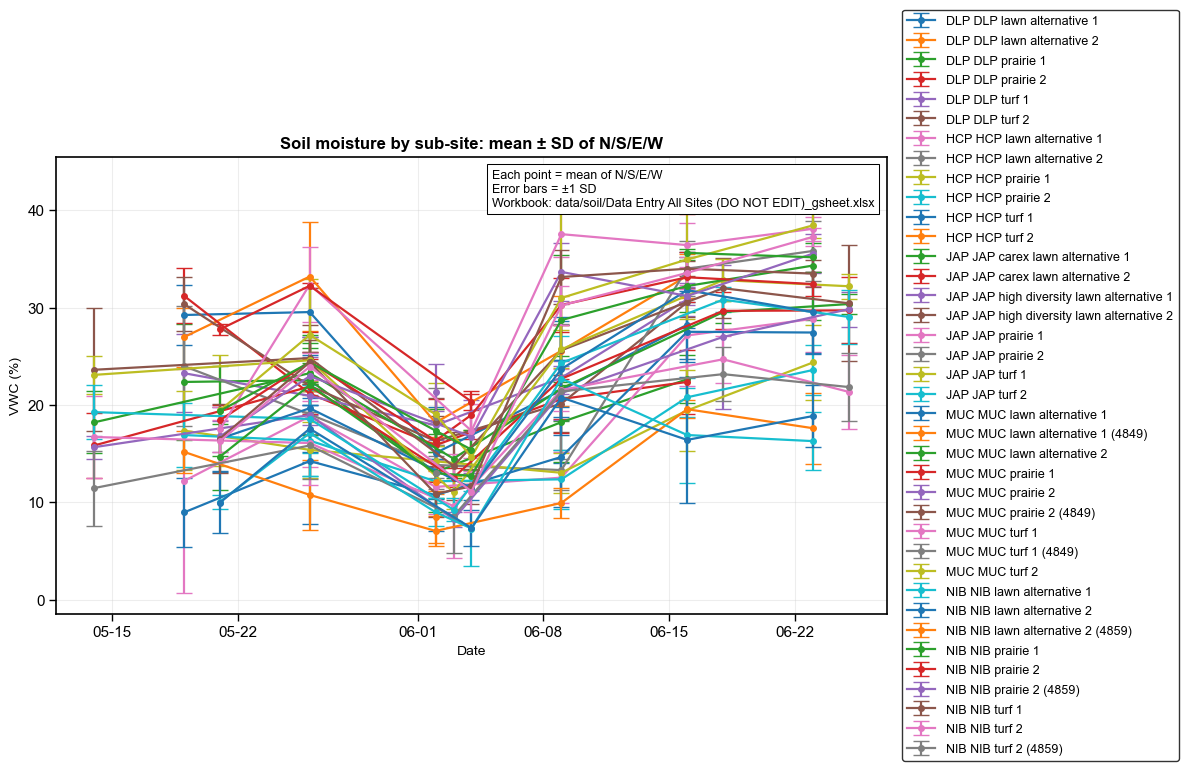

In [34]:
sub_sites_all = list(dict.fromkeys(All["SiteSubSite"]))

fig, ax = plt.subplots(figsize=(12, 7))
for name in sub_sites_all:
    X = All[All["SiteSubSite"] == name].sort_values("Date")
    ax.errorbar(X["Date"], X["MeanVWC"], yerr=X["SDVWC"],
                fmt="-o", linewidth=1.6, markersize=4, capsize=6, label=name)

ax.set_ylabel("VWC (%)", color="k")
ax.set_xlabel("Date", color="k")
ax.set_title("Soil moisture by sub-site: mean \u00b1 SD of N/S/E/W",
             color="k", fontweight="bold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
legend = ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
format_soil_moisture_axes(ax, legend)
add_white_annotation(ax, f"Each point = mean of N/S/E/W\nError bars = \u00b11 SD\nWorkbook: {fileName}")
fig.tight_layout()

if saveFigures:
    png = os.path.join(figDir, "ALL_sites_soil_moisture_timeseries.png")
    fig.savefig(png, dpi=300, facecolor=("w" if exportBackground == "white" else "none"),
                bbox_inches="tight")
    print(f"Saved figure: {png}")
plt.show()

## 9. Combined plot — mean-centered VWC anomaly

Saved figure: figures/ALL_sites_soil_moisture_mean_centered_timeseries.png


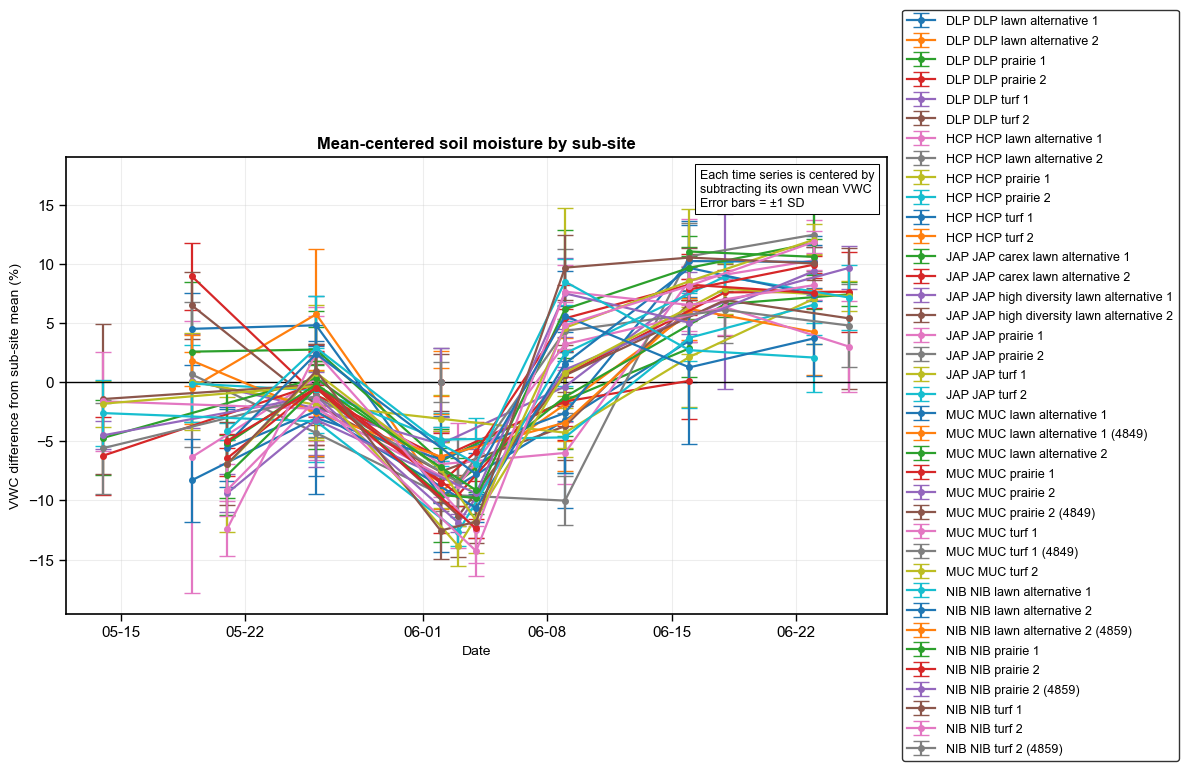

In [35]:
All["AnomalyVWC"] = np.nan
for name in sub_sites_all:
    idx = All["SiteSubSite"] == name
    All.loc[idx, "AnomalyVWC"] = All.loc[idx, "MeanVWC"] - np.nanmean(All.loc[idx, "MeanVWC"])

fig, ax = plt.subplots(figsize=(12, 7))
for name in sub_sites_all:
    X = All[All["SiteSubSite"] == name].sort_values("Date")
    ax.errorbar(X["Date"], X["AnomalyVWC"], yerr=X["SDVWC"],
                fmt="-o", linewidth=1.6, markersize=4, capsize=6, label=name)

ax.axhline(0, color="k", linewidth=1.0)
ax.set_ylabel("VWC difference from sub-site mean (%)", color="k")
ax.set_xlabel("Date", color="k")
ax.set_title("Mean-centered soil moisture by sub-site", color="k", fontweight="bold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
legend = ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
format_soil_moisture_axes(ax, legend)
add_white_annotation(ax, "Each time series is centered by\nsubtracting its own mean VWC\nError bars = \u00b11 SD")
fig.tight_layout()

if saveFigures:
    png = os.path.join(figDir, "ALL_sites_soil_moisture_mean_centered_timeseries.png")
    fig.savefig(png, dpi=300, facecolor=("w" if exportBackground == "white" else "none"),
                bbox_inches="tight")
    print(f"Saved figure: {png}")
plt.show()

## 10. Sensor period (µs)

The period block — the HS2's raw measurement, mislabeled "Conductivity" in the source —
is carried through as `MeanPeriod` / `SDPeriod` and the per-direction `Period_*` columns.
It is not plotted by default, but is available for analysis (e.g. checking for
instrument-related offsets at HCP across the Northwestern/own-unit switch). The cell
below shows period coverage; uncomment the plot to view it.

In [36]:
has_period = "MeanPeriod" in All.columns and All["MeanPeriod"].notna().any()
print("period extracted:", has_period)
if has_period:
    print(All[["Date","Site","SubSite","MeanVWC","MeanPeriod","Serial"]].head(10).to_string(index=False))

# # To plot period the same way as VWC, uncomment:
# fig, ax = plt.subplots(figsize=(12, 7))
# for name in sub_sites_all:
#     X = All[All["SiteSubSite"] == name].sort_values("Date")
#     ax.errorbar(X["Date"], X["MeanPeriod"], yerr=X["SDPeriod"],
#                 fmt="-o", linewidth=1.6, markersize=4, capsize=6, label=name)
# ax.set_ylabel("Period (\u00b5s)", color="k"); ax.set_xlabel("Date", color="k")
# ax.set_title("HS2 period by sub-site: mean \u00b1 SD of N/S/E/W", color="k", fontweight="bold")
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
# legend = ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
# format_soil_moisture_axes(ax, legend); fig.tight_layout(); plt.show()

period extracted: True
      Date Site                SubSite  MeanVWC  MeanPeriod  Serial
2026-05-19  DLP DLP lawn alternative 1   29.250     1.53375     NaN
2026-05-26  DLP DLP lawn alternative 1   29.550     1.55925     NaN
2026-06-02  DLP DLP lawn alternative 1   15.075     1.34275     NaN
2026-06-09  DLP DLP lawn alternative 1   21.525     1.44325     NaN
2026-06-16  DLP DLP lawn alternative 1   28.250     1.54550     NaN
2026-05-19  DLP DLP lawn alternative 2   26.975     1.55300     NaN
2026-05-26  DLP DLP lawn alternative 2   33.200     1.62625     NaN
2026-06-02  DLP DLP lawn alternative 2   18.200     1.39275     NaN
2026-06-09  DLP DLP lawn alternative 2   25.575     1.50475     NaN
2026-06-16  DLP DLP lawn alternative 2   33.275     1.62375     NaN


## 11. VWC vs period scatter — recovering the calibration

The HS2 measures **period** (µs); VWC (%) is derived from it by a proprietary Campbell
algorithm. Plotting one against the other lets us see the empirical relationship and fit
a candidate curve. Each point is one direction reading (N/S/E/W), colored by site.

Saved figure: figures/VWC_vs_period_scatter.png


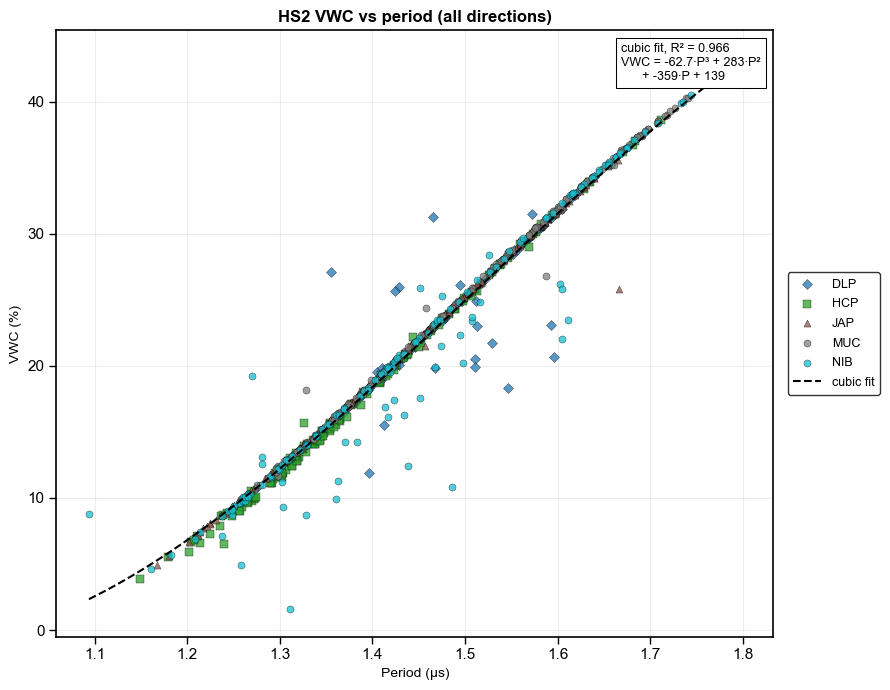

In [37]:
# Per-direction long form: one row per (sub-site, direction) with paired VWC + period.
_dirs = ["N", "S", "E", "W"]
_pairs = []
for d in _dirs:
    vc, pc = f"VWC_{d}", f"Period_{d}"
    if vc in All.columns and pc in All.columns:
        sub = All[["Site", "SiteSubSite", vc, pc]].rename(
            columns={vc: "VWC", pc: "Period"})
        _pairs.append(sub)
pts = pd.concat(_pairs, ignore_index=True).dropna(subset=["VWC", "Period"])

# Marker shape encodes the operating institution (color still encodes site).
site_marker = {"NIB": "o", "MUC": "o",   # UIC
               "HCP": "s",               # NEIU
               "JAP": "^",               # CSU
               "DLP": "D"}               # NU
default_marker = "P"

fig, ax = plt.subplots(figsize=(9, 7))
sites = list(dict.fromkeys(pts["Site"]))
cmap = plt.cm.tab10(np.linspace(0, 1, max(len(sites), 1)))
for color, site in zip(cmap, sites):
    s = pts[pts["Site"] == site]
    ax.scatter(s["Period"], s["VWC"], s=26,
               color=color, marker=site_marker.get(site, default_marker),
               alpha=0.75, edgecolor="k", linewidth=0.3, label=site)

# Candidate fit: cubic in period (the Topp-style polynomial form).
x = pts["Period"].to_numpy()
y = pts["VWC"].to_numpy()
coeffs = np.polyfit(x, y, 3)
xs = np.linspace(x.min(), x.max(), 200)
ax.plot(xs, np.polyval(coeffs, xs), "k--", linewidth=1.5, label="cubic fit")

# Residuals from the fit, carried on pts for the next cell.
pts["VWC_fit"] = np.polyval(coeffs, x)
pts["Residual"] = pts["VWC"] - pts["VWC_fit"]
ss_res = np.nansum(pts["Residual"] ** 2)
ss_tot = np.nansum((y - np.nanmean(y)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
fit_txt = (f"cubic fit, R\u00b2 = {r2:.3f}\n"
           f"VWC = {coeffs[0]:.3g}\u00b7P\u00b3 + {coeffs[1]:.3g}\u00b7P\u00b2\n"
           f"      + {coeffs[2]:.3g}\u00b7P + {coeffs[3]:.3g}")

ax.set_xlabel("Period (\u00b5s)", color="k")
ax.set_ylabel("VWC (%)", color="k")
ax.set_title("HS2 VWC vs period (all directions)", color="k", fontweight="bold")
legend = ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
format_soil_moisture_axes(ax, legend)
add_white_annotation(ax, fit_txt)
fig.tight_layout()

if saveFigures:
    png = os.path.join(figDir, "VWC_vs_period_scatter.png")
    fig.savefig(png, dpi=300, facecolor=("w" if exportBackground == "white" else "none"),
                bbox_inches="tight")
    print(f"Saved figure: {png}")
plt.show()

## 12. Fit residuals by site

Residual = measured VWC − cubic-fit VWC. Points consistently *below* the curve
(negative residual at given period) are the signature of the hidden EC/attenuation
correction pulling VWC down. Grouping residuals by site shows whether that offset is
systematic per location (soil EC) rather than random scatter.

  DLP: median +0.19%, mean -0.04%, SD 2.45%, n=120
  HCP: median -0.02%, mean -0.13%, SD 0.43%, n=144
  JAP: median +0.33%, mean +0.24%, SD 0.75%, n=192
  MUC: median +0.33%, mean +0.32%, SD 0.50%, n=168
  NIB: median +0.23%, mean -0.50%, SD 2.55%, n=152
Saved figure: figures/VWC_fit_residuals_by_site.png


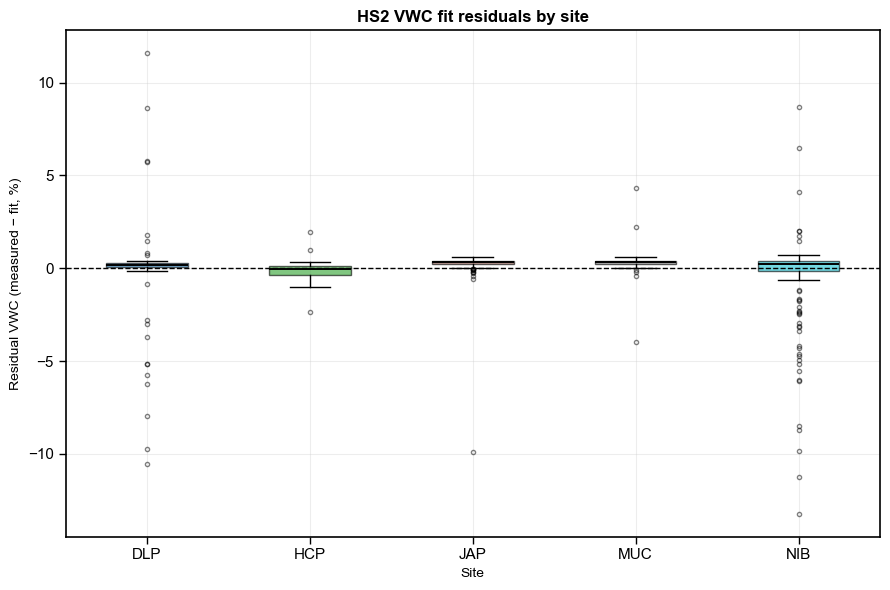

In [38]:
order = list(dict.fromkeys(pts["Site"]))
data = [pts.loc[pts["Site"] == s, "Residual"].dropna().to_numpy() for s in order]

fig, ax = plt.subplots(figsize=(9, 6))
bp = ax.boxplot(data, tick_labels=order, showfliers=True, patch_artist=True,
                medianprops=dict(color="k", linewidth=1.4),
                flierprops=dict(marker="o", markersize=3, alpha=0.5))
cmap = plt.cm.tab10(np.linspace(0, 1, max(len(order), 1)))
for patch, color in zip(bp["boxes"], cmap):
    patch.set_facecolor(color); patch.set_alpha(0.6); patch.set_edgecolor("k")

ax.axhline(0, color="k", linewidth=1.0, linestyle="--")
ax.set_ylabel("Residual VWC (measured \u2212 fit, %)", color="k")
ax.set_xlabel("Site", color="k")
ax.set_title("HS2 VWC fit residuals by site", color="k", fontweight="bold")
format_soil_moisture_axes(ax)
fig.tight_layout()

for s in order:
    r = pts.loc[pts["Site"] == s, "Residual"]
    print(f"  {s}: median {r.median():+.2f}%, mean {r.mean():+.2f}%, "
          f"SD {r.std():.2f}%, n={r.notna().sum()}")

if saveFigures:
    png = os.path.join(figDir, "VWC_fit_residuals_by_site.png")
    fig.savefig(png, dpi=300, facecolor=("w" if exportBackground == "white" else "none"),
                bbox_inches="tight")
    print(f"Saved figure: {png}")
plt.show()

## 14. Land-use VWC anomaly relative to turf

Each site has two replicates of three land-use classes: turf (1, 2), prairie (1, 2),
and lawn alternative (1, 2). Turf is the reference. For each site and date the two turf
replicates are averaged to form a turf baseline VWC; prairie and lawn-alternative
sub-sites are then expressed as anomalies (sub-site mean VWC − site/date turf baseline).
A positive anomaly means that land use holds more water than turf at the same site and time.

In [39]:
def landuse_class(subsite):
    """Map a SubSite name to 'turf', 'prairie', 'lawn_alt', or None."""
    s = str(subsite).lower()
    if "turf" in s:
        return "turf"
    if "prairie" in s:
        return "prairie"
    if "lawn" in s:  # 'lawn alternative 1/2'
        return "lawn_alt"
    return None

lu = All.copy()
lu["LandUse"] = lu["SubSite"].map(landuse_class)
lu = lu[lu["LandUse"].notna()].copy()

# Turf baseline: mean of turf replicates per site + date.
turf_base = (lu[lu["LandUse"] == "turf"]
             .groupby(["Site", "Date"])["MeanVWC"]
             .mean()
             .rename("TurfBaseVWC")
             .reset_index())

lu = lu.merge(turf_base, on=["Site", "Date"], how="left")
lu["AnomVsTurf"] = lu["MeanVWC"] - lu["TurfBaseVWC"]

# Drop turf's own rows from the anomaly view (they're ~0 by construction) and any
# site/date with no turf reference recorded.
alt = lu[(lu["LandUse"] != "turf") & lu["TurfBaseVWC"].notna()].copy()

n_missing = lu["TurfBaseVWC"].isna().sum()
if n_missing:
    print(f"NOTE: {n_missing} rows had no turf baseline for their site/date "
          f"(turf not measured that visit); excluded from anomaly.")

# Per-class summary across all sites.
print("\nAnomaly vs turf (%, + = wetter than turf):")
for cls in ["prairie", "lawn_alt"]:
    r = alt.loc[alt["LandUse"] == cls, "AnomVsTurf"]
    print(f"  {cls:9s} median {r.median():+.2f}  mean {r.mean():+.2f}  "
          f"SD {r.std():.2f}  n={r.notna().sum()}")


Anomaly vs turf (%, + = wetter than turf):
  prairie   median -0.63  mean -0.64  SD 5.06  n=60
  lawn_alt  median -2.21  mean -1.87  SD 6.40  n=74


### Anomaly by site and land use

Saved figure: figures/VWC_anomaly_vs_turf_by_site.png


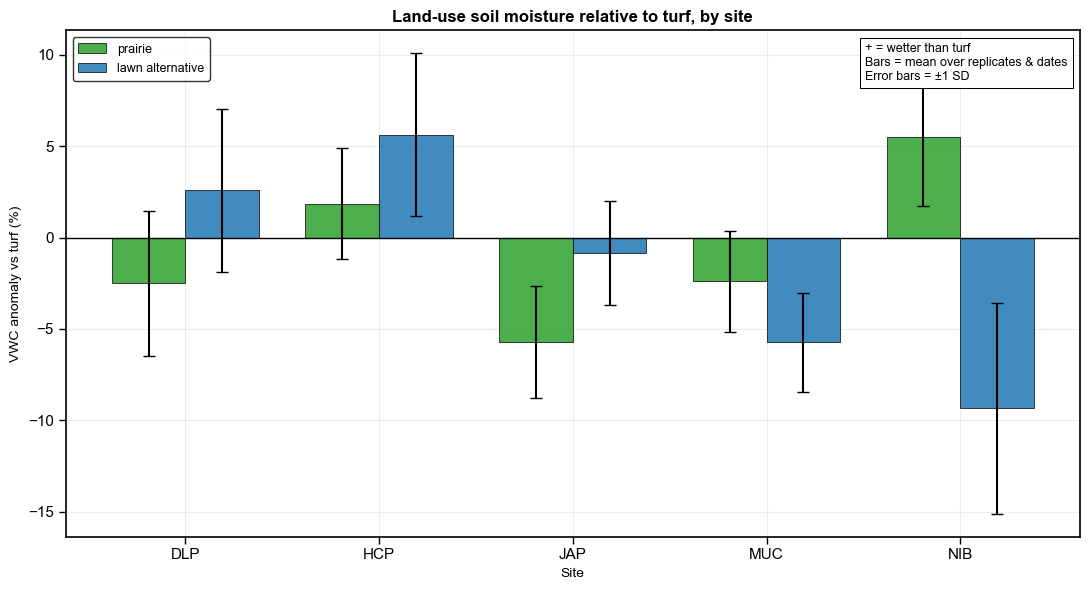

In [41]:
sites = list(dict.fromkeys(alt["Site"]))
classes = ["prairie", "lawn_alt"]
class_label = {"prairie": "prairie", "lawn_alt": "lawn alternative"}
class_color = {"prairie": plt.cm.tab10(2), "lawn_alt": plt.cm.tab10(0)}

# Mean anomaly +/- SD per site x class (averaging the two replicates and all dates).
agg = (alt.groupby(["Site", "LandUse"])["AnomVsTurf"]
          .agg(["mean", "std", "count"])
          .reset_index())

x = np.arange(len(sites))
w = 0.38

fig, ax = plt.subplots(figsize=(11, 6))
for i, cls in enumerate(classes):
    means = [agg[(agg["Site"] == s) & (agg["LandUse"] == cls)]["mean"].squeeze()
             if not agg[(agg["Site"] == s) & (agg["LandUse"] == cls)].empty else np.nan
             for s in sites]
    sds = [agg[(agg["Site"] == s) & (agg["LandUse"] == cls)]["std"].squeeze()
           if not agg[(agg["Site"] == s) & (agg["LandUse"] == cls)].empty else np.nan
           for s in sites]
    ax.bar(x + (i - 0.5) * w, means, w, yerr=sds, capsize=4,
           color=class_color[cls], edgecolor="k", linewidth=0.6,
           alpha=0.85, label=class_label[cls])

ax.axhline(0, color="k", linewidth=1.0)
ax.set_xticks(x)
ax.set_xticklabels(sites)
ax.set_ylabel("VWC anomaly vs turf (%)", color="k")
ax.set_xlabel("Site", color="k")
ax.set_title("Land-use soil moisture relative to turf, by site",
             color="k", fontweight="bold")
legend = ax.legend(loc="upper left")
format_soil_moisture_axes(ax, legend)
add_white_annotation(ax, "+ = wetter than turf\nBars = mean over replicates & dates\nError bars = \u00b11 SD")
fig.tight_layout()

if saveFigures:
    png = os.path.join(figDir, "VWC_anomaly_vs_turf_by_site.png")
    fig.savefig(png, dpi=300, facecolor=("w" if exportBackground == "white" else "none"),
                bbox_inches="tight")
    print(f"Saved figure: {png}")
plt.show()